## Generating base dataset from plain chart files

In [23]:
import glob
import re
from enum import IntEnum
from pathlib import Path
from typing import Annotated, Literal

from pydantic import BaseModel, Field

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import seaborn as sns


class SlidePattern(IntEnum):
    no_slide = 0
    straight = 1
    ccw_edge = 2
    cw_edge = 3
    ccw_centre_arc = 4
    cw_centre_arc = 5
    zigzag_s = 6
    zigzag_z = 7
    straight_centre_end = 8
    straight_centre_ccw_end = 9
    straight_centre_cw_end = 10
    ccw_grand_v = 11
    cw_grand_v = 12
    fan = 13


class ChartDifficulty(IntEnum):
    easy = 1
    basic = 2
    advanced = 3
    expert = 4
    master = 5
    re_master = 6


class SDTRowWithChartDifficulty(BaseModel):
    whole_measure: int = Field(ge=0)
    fractional_measure: float = Field(ge=0, le=1) # SCT Can have this as 1, look into this
    duration: float = Field(ge=0)
    location: int = Literal[0, 1, 2, 3, 4, 5, 6, 7]
    note_type: int = Literal[0, 1, 2, 3, 4, 5, 128]
    slide_id: int = Field(ge=0)
    slide_pattern: SlidePattern
    slide_amount: int = Field(ge=0)
    slide_delay: float = Field(ge=0)

    difficulty: ChartDifficulty


class SlideParams(BaseModel):
    star_duration: float = Field(ge=0)
    slide_duration: float = Field(ge=0)
    slide_delay: float = Field(ge=0)
    distance: int = Literal[0, 1, 2, 3, 4, 5, 6, 7, 8]
    # end: int = Literal[0, 1, 2, 3, 4, 5, 6, 7]
    slide_pattern: SlidePattern
    difficulty: ChartDifficulty
    version: str


def get_clockwise_slide_distance(start_location: int, end_location: int) -> int:
    return abs(start_location - end_location)


def get_counter_clockwise_slide_distance(start_location: int, end_location: int) -> int:
    return 7 - abs(start_location - end_location)


def get_shortest_slide_distance(start_location: int, end_location: int) -> int:
    return min(
        get_clockwise_slide_distance(start_location, end_location),
        get_counter_clockwise_slide_distance(start_location, end_location)
    )


def get_distance_for_slide(start_location: int, end_location: int, slide_pattern: SlidePattern) -> int:
    match slide_pattern.value:
        case SlidePattern.no_slide.value:
            raise ValueError('`no_slide` cannot be used to calculate slide distance.')

        case SlidePattern.straight.value:
            return get_shortest_slide_distance(start_location, end_location)

        case SlidePattern.ccw_edge.value:
            return get_counter_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.cw_edge.value:
            return get_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.ccw_centre_arc.value:
            return get_counter_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.cw_centre_arc.value:
            return get_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.zigzag_s.value | SlidePattern.zigzag_z.value:
            return get_shortest_slide_distance(start_location, end_location)

        case SlidePattern.straight_centre_end.value:
            return get_shortest_slide_distance(start_location, end_location)

        case SlidePattern.straight_centre_ccw_end.value:
            return get_counter_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.straight_centre_cw_end.value:
            return get_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.ccw_grand_v.value:
            return get_counter_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.cw_grand_v.value:
            return get_clockwise_slide_distance(start_location, end_location)

        case SlidePattern.fan.value:
            return get_shortest_slide_distance(start_location, end_location)

    raise ValueError(f'Unrecognized slide pattern_group type {slide_pattern} {type(slide_pattern)}.')


# Exclude utage chart files, and exclude SRT
plain_non_utage_charts = glob.glob("plain charts/*_0[123456]*.s[cdz]t")

# sdt_pattern = re.compile(r"")
df = pd.DataFrame(columns=["star_duration", "slide_duration", "distance", "slide_pattern", "difficulty", "version"])

notes: list[SDTRowWithChartDifficulty] = []

slide_params: list[SlideParams] = []

for chart in plain_non_utage_charts:
    chart_path = Path(chart)
    with open(chart_path, "r") as f:
        chart_lines = f.readlines()
        # Get all components of the chart, remove whitespace and empty sets from blank lines
        chart_component_sets = [
            [str.strip(component) for component in chart_line.split(',') if str.strip(component)]
            for chart_line in chart_lines if str.strip(chart_line)
        ]

        rows = []

        chart_version = chart_path.suffix[1:]
        chart_difficulty = int(chart_path.stem.split("_")[-1])

        match chart_path.suffix:
            case ".sdt":
                rows = [SDTRowWithChartDifficulty(whole_measure=row[0], fractional_measure=row[1], duration=row[2], location=row[3],
                                                  note_type=row[4],
                                                  slide_id=row[5], slide_pattern=row[6], slide_amount=row[7], slide_delay=row[8],
                                                  difficulty=chart_difficulty)
                        for row in chart_component_sets]

            case ".sct":
                rows = [SDTRowWithChartDifficulty(whole_measure=row[0], fractional_measure=row[1], duration=row[2], location=row[3],
                                                  note_type=row[4],
                                                  slide_id=row[5], slide_pattern=row[6], slide_amount=row[7], slide_delay=0.25,
                                                  difficulty=chart_difficulty)
                        for row in chart_component_sets]

            case ".szt":
                rows = [SDTRowWithChartDifficulty(whole_measure=row[0], fractional_measure=row[1], duration=row[2], location=row[3],
                                                  note_type=row[4],
                                                  slide_id=row[5], slide_pattern=row[6], slide_amount=1, slide_delay=0.25,
                                                  difficulty=chart_difficulty)
                        for row in chart_component_sets]

        for potential_star in rows:
            if potential_star.note_type == 4 or potential_star.note_type == 5:
                slides_param_sets: list[SlideParams] = []

                slides = [i for i in rows if i.note_type == 0
                          and i.whole_measure == potential_star.whole_measure
                          and i.fractional_measure == potential_star.fractional_measure]

                for slide in slides:
                    end_slide = [i for i in rows if i.note_type == 128 and i.slide_id == slide.slide_id]
                    # Each start slide should have only one end slide
                    assert len(end_slide) == 1

                    end_slide = end_slide[0]

                    slides_param_sets.append(SlideParams(
                        star_duration=potential_star.duration,
                        slide_duration=slide.duration,
                        distance=get_clockwise_slide_distance(
                            potential_star.location, end_slide.location
                        ),
                        slide_pattern=slide.slide_pattern,
                        version=chart_version,
                        slide_delay=slide.slide_delay,

                        difficulty=potential_star.difficulty
                    ))

                slide_params.extend(slides_param_sets)

            notes.extend(rows)

# Get all slides found in the game as a single dataframe
full_df = pd.DataFrame(
    data=[
        [params.star_duration, params.slide_duration, params.slide_delay, params.distance,
         params.slide_pattern, params.difficulty, params.version]
        for params in slide_params],
    columns=["star_duration", "slide_duration", "slide_delay", "distance", "pattern_group", "difficulty", "version"]
)
# Remove duplicates to find patterns between different configurations over huge groups of identical slide
pruned_df = full_df.drop_duplicates()

pruned_df['duration_ratio']            = pruned_df['star_duration'] / pruned_df['slide_duration']
pruned_df['duration_with_delay']       = pruned_df['slide_duration'] + pruned_df['slide_delay']
pruned_df['duration_with_delay_ratio'] = pruned_df['star_duration'] / pruned_df['duration_with_delay']

pruned_df

,star_duration,slide_duration,slide_delay,distance,pattern_group,difficulty,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
0,0.352896,1.000,0.25,3,3,6,szt,0.352896,1.250,0.282317
1,0.352896,1.000,0.25,3,2,6,szt,0.352896,1.250,0.282317
4,0.125000,0.375,0.25,3,1,6,szt,0.333333,0.625,0.200000
6,0.115485,0.375,0.25,4,1,6,szt,0.307960,0.625,0.184776
13,0.125000,0.375,0.25,5,1,6,szt,0.333333,0.625,0.200000
...,...,...,...,...,...,...,...,...,...,...
119660,0.106800,0.375,0.25,7,3,4,sdt,0.284800,0.625,0.170880
119816,0.555600,1.000,0.25,3,5,5,sdt,0.555600,1.250,0.444480
119817,0.555600,1.000,0.25,3,4,5,sdt,0.555600,1.250,0.444480
119897,0.202700,0.625,0.25,1,11,5,sdt,0.324320,0.875,0.231657


## Preparing data for averages by pattern, distance and difficulty

In [24]:
# Group by pattern and difficulty for filtering (since that represents a single bar for the next cell)
groups = pruned_df.groupby(['pattern_group', 'difficulty'])
# Only include data within 3 standard deviations of the mean
star_spin_ratio_df_bar_outliers = groups.apply(lambda group: group[np.abs(stats.zscore(group['duration_ratio'])) < 3]).reset_index()

star_spin_ratio_df_bar_outliers

,pattern_group,difficulty,level_2,star_duration,slide_duration,slide_delay,distance,version,duration_ratio,duration_with_delay,duration_with_delay_ratio
0,1,1,2475,1.154849,1.5000,0.2500,4,szt,0.769899,1.7500,0.659914
1,1,1,3484,0.750000,1.0000,0.2500,3,szt,0.750000,1.2500,0.600000
2,1,1,4393,0.750000,1.0000,0.2500,5,szt,0.750000,1.2500,0.600000
3,1,1,5425,0.750000,1.0000,0.2500,5,sdt,0.750000,1.2500,0.600000
4,1,1,5426,0.750000,1.0000,0.2500,3,sdt,0.750000,1.2500,0.600000
...,...,...,...,...,...,...,...,...,...,...,...
15267,13,6,98536,0.347200,0.6250,0.2500,4,sdt,0.555520,0.8750,0.396800
15268,13,6,102439,0.173600,0.6875,0.5000,4,sdt,0.252509,1.1875,0.146189
15269,13,6,104097,0.173600,0.3125,0.1250,4,sdt,0.555520,0.4375,0.396800
15270,13,6,107493,0.205200,2.8802,2.6586,4,sdt,0.071245,5.5388,0.037048


## Visualising slides by pattern, distance and difficulty

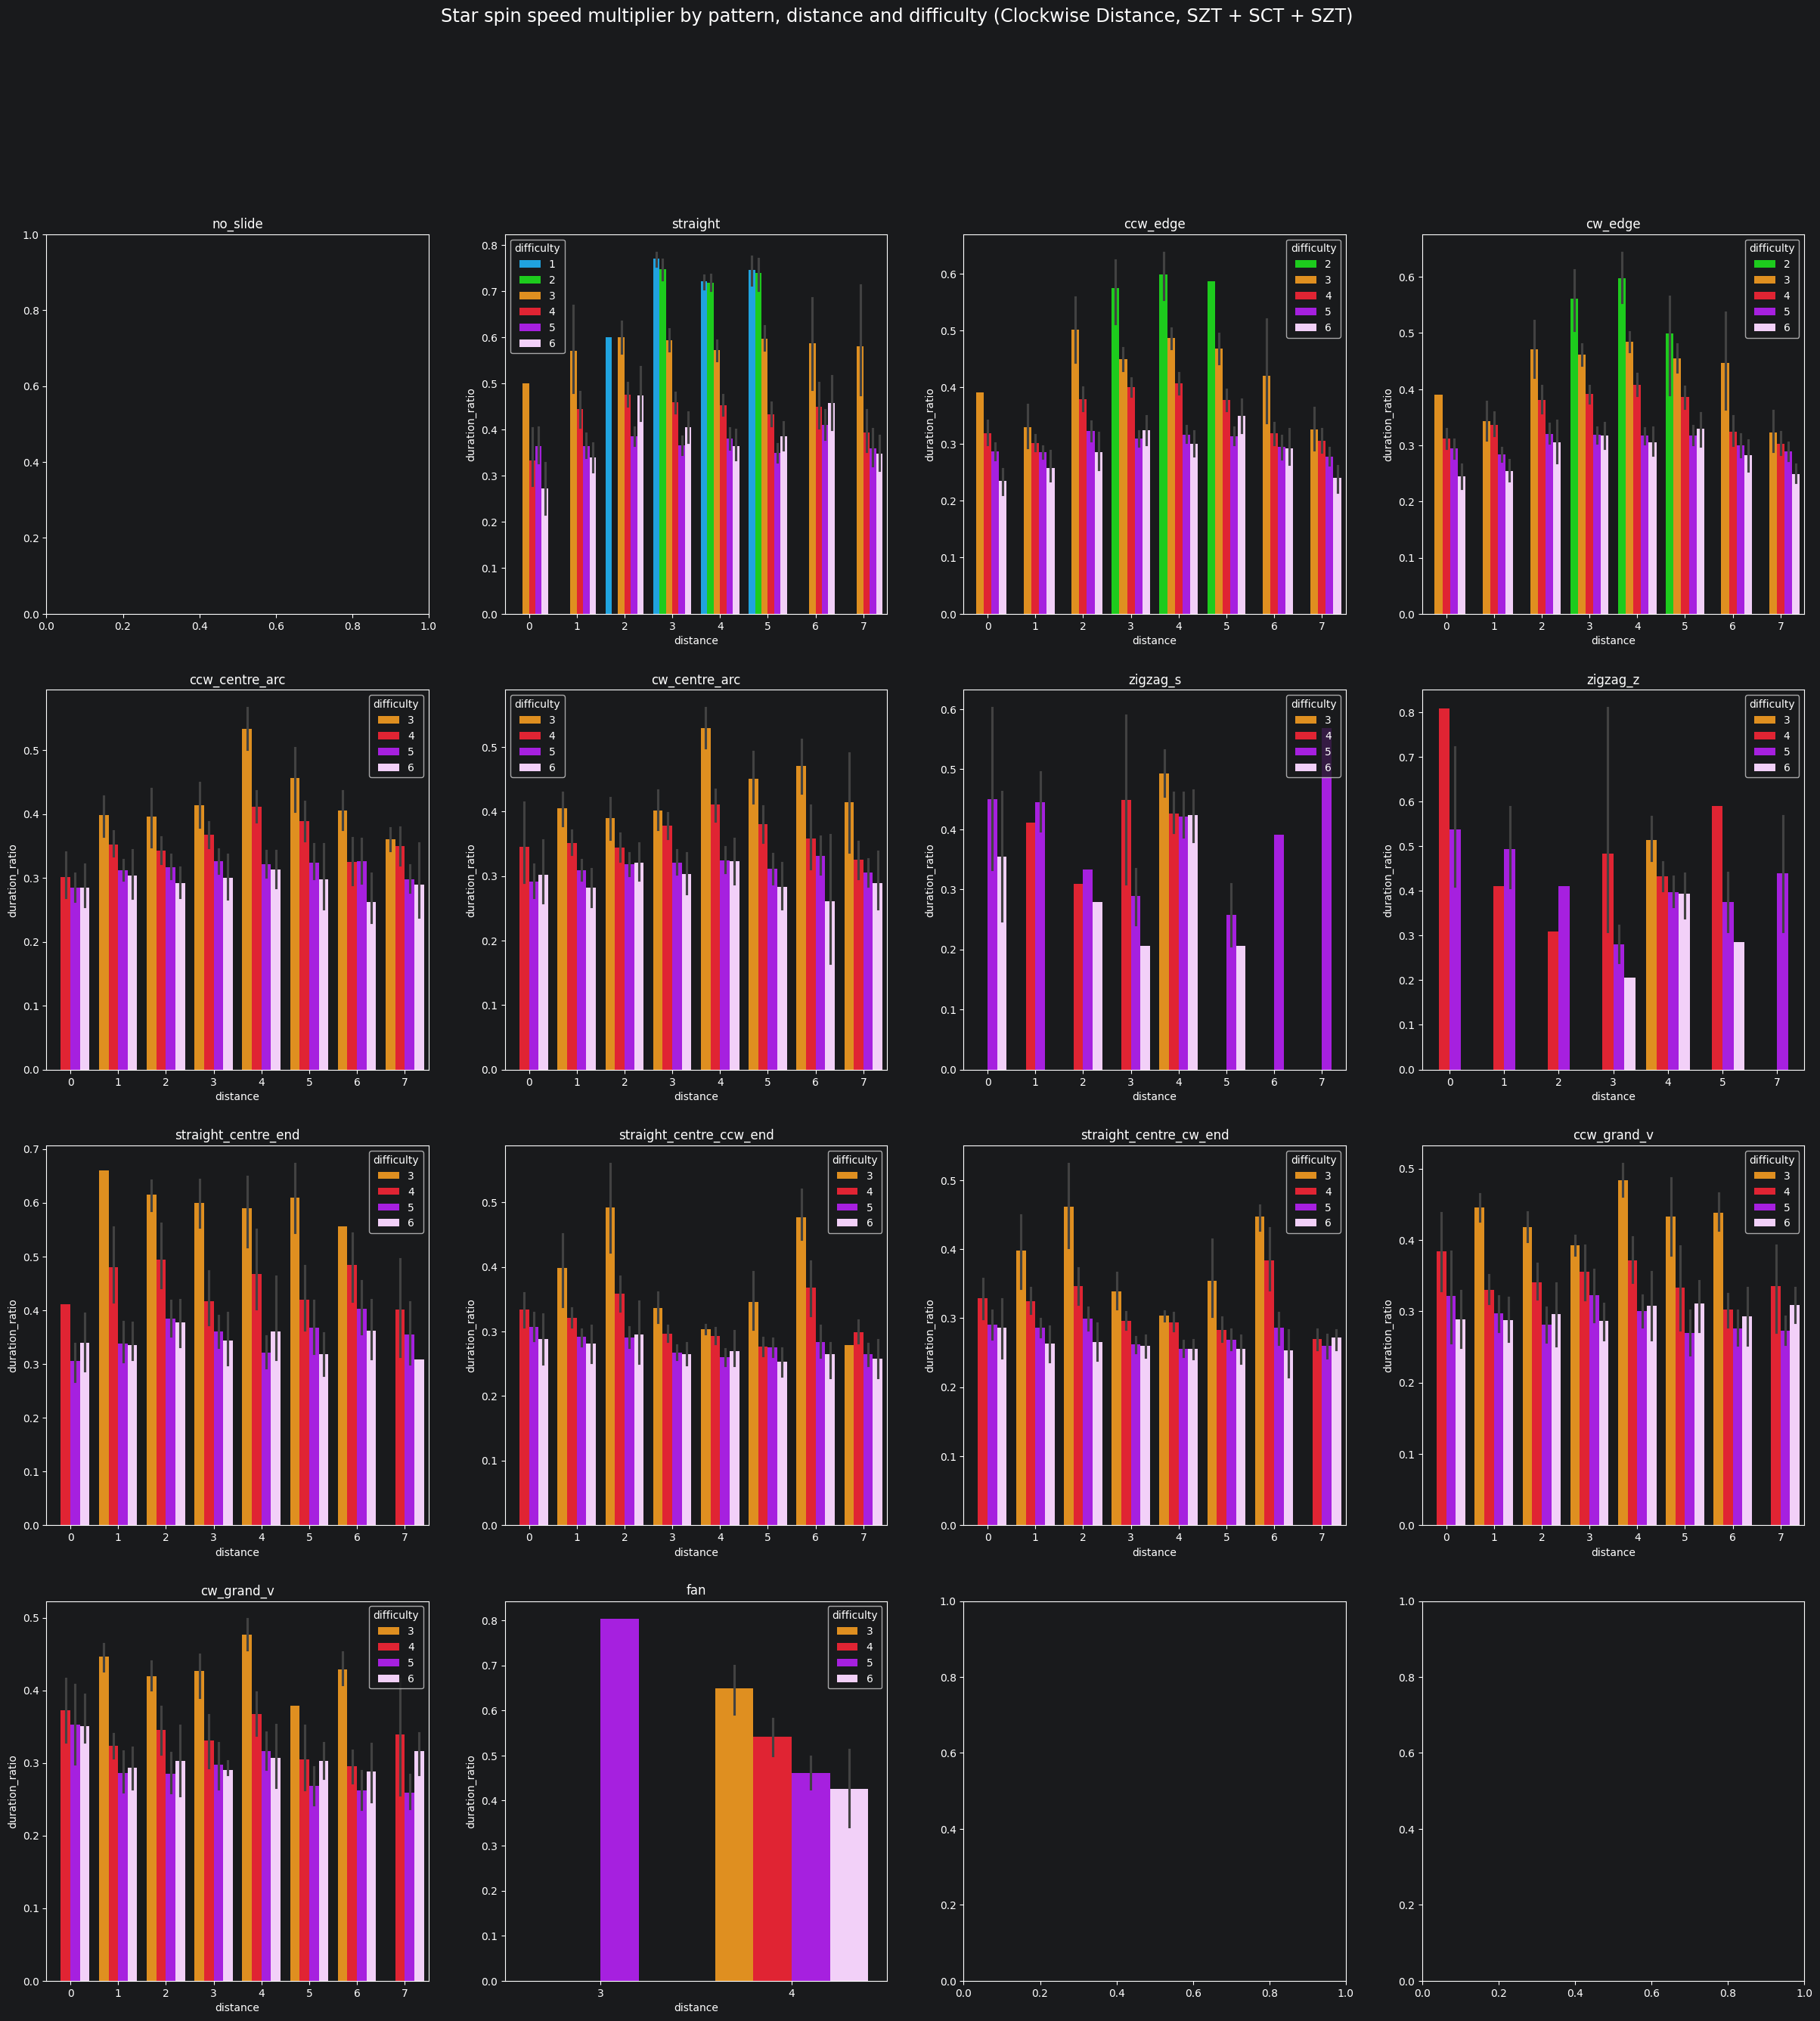

In [27]:
difficulty_colours = {
    1: '#00afff',
    2: '#00e800',
    3: '#ff9400',
    4: '#ff0519',
    5: '#b300ff',
    6: '#f6c9ff',
}

# sns.color_palette(difficulty_colours)

fig, axs = plt.subplots(ncols=4, nrows=4)
fig.suptitle('Star spin speed multiplier by pattern, distance and difficulty (Clockwise Distance, SZT + SCT + SZT)', size='xx-large')

# TODO: Find charts with incorrect zigzag Zs
# TODO: Look into why chart is flipped between pattern CW and CCW (are calculations for distance correct?)

pattern_groups: tuple[tuple[str, tuple[SlidePattern, ...]], ...] = (
    ('Straight Line', (SlidePattern.straight,)),
    ('Edge Circle', (SlidePattern.cw_edge, SlidePattern.ccw_edge)),
    ('Centre Arc', (SlidePattern.cw_centre_arc, SlidePattern.ccw_centre_arc)),
    ('Zigzag', (SlidePattern.zigzag_s, SlidePattern.zigzag_z)),
    ('Straight - Centre - End', (SlidePattern.straight_centre_end,)),
    ('Straight - Arc - End', (SlidePattern.straight_centre_ccw_end, SlidePattern.straight_centre_cw_end)),
    ('Grand V', (SlidePattern.ccw_grand_v, SlidePattern.cw_grand_v)),
    ('Fan', (SlidePattern.fan,))
)

for count, pattern_group in enumerate(SlidePattern):
    pattern_df = star_spin_ratio_df_bar_outliers.loc[star_spin_ratio_df_bar_outliers['pattern_group'] == pattern_group]

    plot = sns.barplot(data=pattern_df, x="distance", y="duration_ratio", hue="difficulty", palette=difficulty_colours,
                       ax=axs[count // 4][count % 4]).set(title=pattern_group.name)

fig.set_size_inches(30, 30)

fig.savefig(f"pruned_slides_grouped_clockwise_difficulties_sdt+sct.png")

## TODO: Graph data including delay for spin ratio, move graphing code to functions where possible